# Causal Methods for Time Series

*Part 12 of a practical time-series series — the sequel to the VAR / cointegration notebook.*

Autoregression is the simplest form of memory a series can have. Once we move from one series to several, the interesting question stops being *"what happens next?"* and becomes *"which series moves which?"* — that is, **causality**. This notebook climbs a ladder of methods that answer progressively harder versions of that question:

* **Vector Autoregression (VAR)** — joint linear prediction across several series.
* **Granger causality** — does one series' past help predict another's future?
* **Cointegration** — do non-stationary series share a stable long-run equilibrium?
* **Vector Error Correction (VECM)** — modelling short-run moves *and* the pull back to equilibrium.
* **Toda–Yamamoto** — testing causality robustly when we are unsure about stationarity.
* **Structural VAR (SVAR)** — recovering *contemporaneous* (same-period) causal direction.

Each rung adds exactly one new idea to the rung below it. We lean heavily on **simulated systems whose true causal structure we choose ourselves**, so that we can check whether each method actually recovers the answer we built in — and we finish on a real macroeconomic dataset.

> A recurring theme: every method here measures a *specific, narrow* notion of causality. Knowing which notion is the whole game.

# Setup

In [1]:
# Standard library imports
import warnings
import io
import contextlib

# Third-party imports — core data -> modelling -> visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# statsmodels: the engine room for everything in this notebook
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests, coint
from statsmodels.tsa.vector_ar.vecm import (
    coint_johansen, select_coint_rank, select_order, VECM,
)
from statsmodels.datasets import macrodata

from scipy import stats

# Configuration & settings
warnings.simplefilter(action="ignore")            # keep teaching output clean

The imports are grouped the way we will use them. A few words on each, since the whole notebook rests on this cell.

The **standard-library** block brings in `warnings` (to silence the cosmetic deprecation and interpolation warnings statsmodels emits), plus `io` and `contextlib`, which we will use to capture one chatty function's printed output instead of letting it flood the notebook.

The **third-party** block follows the usual data-science order. `numpy` (aliased to `np`, a community convention so we can write `np.array` instead of the full module name) is the numerical array library; `pandas` (`pd`) gives us the `DataFrame`, a labelled table that keeps a series and its time index glued together; `matplotlib.pyplot` (`plt`) is the plotting workhorse.

The **statsmodels** block is the substance. `AutoReg` fits a single-series autoregression — our simplest rung. `VAR` is its multivariate generalisation. From `stattools` we pull the diagnostic tests: `adfuller` and `kpss` for stationarity, `grangercausalitytests` for predictive precedence, and `coint` for the Engle–Granger cointegration test. The `vecm` module supplies the cointegration machinery — the Johansen test (`coint_johansen`), its rank selector (`select_coint_rank`), a lag-order selector (`select_order`), and the error-correction model itself (`VECM`). `macrodata` is a real, offline US macro dataset we use for the capstone. Finally `scipy.stats` gives us the chi-squared distribution we need to build the Toda–Yamamoto test by hand.

`warnings.simplefilter("ignore")` switches off warnings globally. In production you would be more surgical, but in a teaching notebook the warnings are noise that distracts from the statistics.

In [2]:
# general settings
class CFG:
    img_dim1 = 14          # default figure width
    img_dim2 = 6           # default figure height
    SEED = 42              # global seed for reproducibility
    signif = 0.05          # significance level used across all tests

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

np.random.seed(CFG.SEED)

This `CFG` idiom — a bare class used purely as a namespace for constants — recurs in every notebook of the series. Bundling the figure dimensions, the random seed, and the significance level in one place means there is a single, named home for every "knob"; if we later want wider figures or a 1% significance level, we change one line here rather than hunting through forty cells.

`plt.style.use("seaborn-v0_8")` applies a clean, grid-lined aesthetic, and the `rcParams` line makes every subsequent plot use our default size without us repeating it.

`np.random.seed(CFG.SEED)` seeds NumPy's *legacy* global generator. Most of our simulations below use the newer `np.random.default_rng(seed)` API (which takes its own seed and does not touch global state), but seeding the global generator as well guarantees that any statsmodels internals relying on it behave identically every run. The specific value — 42 — is arbitrary; what matters is that it is *fixed*, so the random series we generate, and therefore every number and plot below, are reproducible.

# Utils

Anything we do more than twice becomes a small, well-named helper here, so the body cells below read as short declarative calls. We build six: a metrics function, a stationarity reporter, a chronological splitter, a plotting wrapper, a Granger-test wrapper, and the Toda–Yamamoto test.

In [3]:
def forecast_metrics(actual, predicted):
    """Return MAE and RMSE between two aligned arrays, rounded for display."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mae = float(np.round(np.mean(np.abs(actual - predicted)), 4))
    rmse = float(np.round(np.sqrt(np.mean((actual - predicted) ** 2)), 4))
    return {"MAE": mae, "RMSE": rmse}

`forecast_metrics` takes the realised values and a forecast, coerces both to float arrays with `np.asarray` (so it works whether we pass a list, a NumPy array, or a pandas Series), and returns a small dictionary with two scores. **MAE** (mean absolute error) is the average size of the miss in the series' own units; **RMSE** (root mean squared error) squares the errors before averaging, which penalises large misses more heavily. We round to four decimals and cast to plain `float` so the dictionary prints cleanly rather than showing `np.float64(...)` wrappers. Returning a dict rather than printing lets callers collect many results into a table.

In [4]:
def run_stationarity(df, signif=CFG.signif):
    """Tidy ADF + KPSS report for every column. The two tests have OPPOSITE nulls."""
    rows = []
    for c in df.columns:
        s = df[c].dropna()                       # both tests choke on NaNs
        adf_p = adfuller(s)[1]                    # H0: unit root (non-stationary)
        kpss_p = kpss(s, regression="c", nlags="auto")[1]   # H0: stationary
        rows.append({
            "series": c,
            "ADF p": round(adf_p, 3),
            "ADF -> stationary?": adf_p < signif,
            "KPSS p": round(kpss_p, 3),
            "KPSS -> stationary?": kpss_p > signif,
        })
    return pd.DataFrame(rows).set_index("series")

`run_stationarity` loops over the columns of a DataFrame, runs two complementary unit-root tests on each, and returns a tidy table.

The crucial teaching point is that the two tests have *mirror-image* null hypotheses. The **Augmented Dickey–Fuller (ADF)** test takes "the series has a unit root, i.e. is non-stationary" as its null, so a *small* p-value lets us reject non-stationarity and conclude the series is **stationary**. The **KPSS** test flips this: its null is "the series is stationary," so a *small* p-value is evidence *against* stationarity. We therefore record `ADF -> stationary?` as `adf_p < signif` but `KPSS -> stationary?` as `kpss_p > signif`. When the two agree the verdict is solid; when they disagree the series is borderline and deserves a closer look. We call `.dropna()` first because both routines raise on missing values, and `nlags="auto"` lets KPSS choose its own truncation lag. Stationarity matters enormously here: a VAR estimated on non-stationary levels produces biased standard errors and spurious inference, so this is the very first thing we check on any new dataset.

In [5]:
def train_valid_split(df, cutoff):
    """Chronological split. `cutoff` is positional; negative counts from the end."""
    return df.iloc[:cutoff].copy(), df.iloc[cutoff:].copy()

`train_valid_split` carves a DataFrame into an earlier training block and a later validation block at a positional `cutoff` (a negative value, e.g. `-24`, means "hold out the last 24 rows"). The split is strictly **chronological** — we never shuffle. With time series, shuffling would let the model peek at the future to predict the past, which inflates scores and tests nothing useful. Holding out the *most recent* slice instead simulates the real task: standing at a point in time and forecasting genuinely unseen future data. The `.copy()` calls hand back independent frames, so when we later attach forecast columns to the validation set we do not trip pandas' chained-assignment warnings.

In [6]:
def plot_multi(df, title, ylabel=""):
    """Consistent multi-series line plot: observed series as solid lines, lw=2."""
    ax = df.plot(linewidth=2, xlabel="")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    plt.legend(loc="best")
    plt.show()

`plot_multi` is our standard wrapper for drawing several series at once. We use pandas' own `.plot()` (rather than hand-rolling matplotlib) because it reads the column names and the time index straight off the DataFrame and labels the axes and legend for free. Fixing the convention here — observed series drawn as solid lines with `linewidth=2`, a title, and an explicit legend — means every raw-data plot in the notebook looks the same, so the reader can compare figures at a glance. We pass `xlabel=""` to suppress the redundant index label. Later, when we overlay *fitted* or *forecast* values on top of observed data, we will reach for raw matplotlib and a fixed colour code (fitted in red, forecasts in green dashed with circular markers) so those richer plots also stay mutually consistent.

In [7]:
def granger_pvalue(df, cause, effect, maxlag):
    """Bivariate Granger test: 'does `cause` help predict `effect`?'.

    Returns the SSR-based F-test p-value at each lag 1..maxlag.
    statsmodels prints a report by default; we capture and discard it.
    """
    with contextlib.redirect_stdout(io.StringIO()):
        out = grangercausalitytests(df[[effect, cause]], maxlag=maxlag)
    return {lag: float(np.round(out[lag][0]["ssr_ftest"][1], 4)) for lag in out}

`granger_pvalue` wraps statsmodels' `grangercausalitytests`. Two practical wrinkles are worth flagging. First, **column order matters**: the function tests whether the *second* column Granger-causes the *first*, so to ask "does `cause` help predict `effect`?" we must hand it `df[[effect, cause]]` in that order — a classic gotcha that silently reverses the question if you get it wrong. Second, the function insists on printing a multi-line report for every lag; we wrap the call in `contextlib.redirect_stdout(io.StringIO())` to swallow that output and return just the numbers. We extract the **SSR-based F-test** p-value (`out[lag][0]["ssr_ftest"][1]`) at each lag and collect them into a dictionary keyed by lag, so the caller sees a clean `{1: 0.0004, 2: 0.0}` rather than a wall of text.

In [8]:
def toda_yamamoto(df, cause, effect, p, d_max, signif=CFG.signif):
    """Toda-Yamamoto Granger non-causality test; valid for I(0)/I(1)/cointegrated data.

    Fit a levels VAR of order (p + d_max); Wald-test ONLY the first p lags of `cause`
    in the `effect` equation, leaving the d_max augmenting lags unrestricted.
    """
    cols = list(df.columns)
    res = VAR(df).fit(p + d_max, trend="c")          # intentionally over-fitted
    names = list(res.params.index)                   # const, L1.x1, L1.x2, ...
    b = res.params[effect].values                    # coeffs in the effect equation
    nparams = len(names)

    # pull the covariance block belonging to the effect equation
    eff = cols.index(effect)
    V_full = res.cov_params().values
    V = V_full[eff * nparams:(eff + 1) * nparams,
               eff * nparams:(eff + 1) * nparams]

    # restrict ONLY lags 1..p of `cause` (ignore the d_max augmenting lags)
    rows = [i for i, nm in enumerate(names)
            if nm in {f"L{lag}.{cause}" for lag in range(1, p + 1)}]
    R = np.zeros((len(rows), nparams))
    for r, i in enumerate(rows):
        R[r, i] = 1.0

    Rb = R @ b
    wald = float(Rb.T @ np.linalg.inv(R @ V @ R.T) @ Rb)
    pval = float(stats.chi2.sf(wald, df=len(rows)))
    return {"wald": round(wald, 3), "df": len(rows), "p": round(pval, 4),
            "causes?": pval < signif}

`toda_yamamoto` is the one test in the notebook that statsmodels does not ship ready-made, so we build it. The mechanics will make full sense when we reach its section; for now, read it as a recipe. We fit a VAR in **levels** whose order is *deliberately too high* — the chosen lag `p` plus `d_max`, the maximum order of integration we suspect in the data. From the fitted model we grab the coefficient vector `b` for the `effect` equation and the matching diagonal block `V` of the parameter covariance matrix (statsmodels stacks all equations' covariances together, so we slice out the block for our equation). We then build a restriction matrix `R` that picks out **only the first `p` lags** of the `cause` variable, pointedly ignoring the `d_max` extra "augmenting" lags. The quadratic form `(Rb)' (R V R')^{-1} (Rb)` is a **Wald statistic** that — thanks to those extra lags — follows a clean chi-squared distribution with `len(rows)` degrees of freedom, *regardless of whether the series are stationary or not*. A small p-value means `cause` Granger-causes `effect`. The "why this works" is the subject of its own section later.

# Groundwork: a controlled system and the first-look toolkit

Before any modelling, we manufacture data whose causal structure we already know, so that every method below can be graded against the truth. We will reuse two simulated systems throughout: a **stationary** one here (for VAR, Granger, and SVAR) and a **non-stationary, cointegrated** one later (for cointegration, VECM, and Toda–Yamamoto).

In [9]:
def simulate_var_chain(n=600, burn_in=50, seed=CFG.SEED):
    """A stationary VAR(1) with a known causal CHAIN: x1 -> x2 -> x3.

    x1 is exogenous; x2 is driven by lagged x1; x3 is driven by lagged x2.
    There is NO direct x1 -> x3 link and NO feedback.
    """
    rng = np.random.default_rng(seed)
    e = rng.normal(0, 1, size=(n, 3))
    x = np.zeros((n, 3))
    for t in range(1, n):
        x[t, 0] = 0.5 * x[t-1, 0]                       + e[t, 0]
        x[t, 1] = 0.4 * x[t-1, 1] + 0.5 * x[t-1, 0]     + e[t, 1]   # x1 -> x2
        x[t, 2] = 0.3 * x[t-1, 2] + 0.5 * x[t-1, 1]     + e[t, 2]   # x2 -> x3
    return pd.DataFrame(x[burn_in:], columns=["x1", "x2", "x3"])

`simulate_var_chain` hand-builds a three-variable system whose every coefficient we control, so the "right answer" is known. Reading the loop top to bottom: `x1` depends only on its own past — it is **exogenous**, the upstream driver. `x2` depends on its own past *and* on **lagged `x1`** (the `0.5 * x[t-1, 0]` term), so `x1` causes `x2`. `x3` depends on its own past *and* on **lagged `x2`**, so `x2` causes `x3`. Crucially there is **no direct `x1 -> x3` term** and **no feedback** anywhere: the true graph is a clean chain `x1 -> x2 -> x3`.

This design is deliberate. It lets us pose two questions every causal method should get right: does the method recover the genuine links (`x1 -> x2`, `x2 -> x3`), and does it correctly report that `x1` affects `x3` only *indirectly*, through `x2`? The self-coefficients (0.5, 0.4, 0.3) are all well below 1, which keeps the system **stationary**. We use `np.random.default_rng(seed)` for an isolated, reproducible stream of Gaussian shocks `e`, and we discard the first `burn_in` rows so the series has forgotten its arbitrary all-zero starting point before we observe it.

In [10]:
chain = simulate_var_chain()
chain.head(3)

,x1,x2,x3
0,-0.452757,-1.173500,-1.529125
1,-0.712687,-0.749561,0.722443
2,-0.226069,0.326572,-0.657343


We generate the system and peek at the first three rows with `head(3)` — a quick sanity check that we have a clean three-column numeric frame indexed 0, 1, 2, … as expected. (Using an integer index is fine here; the *order* is what matters for autoregression, not calendar dates.)

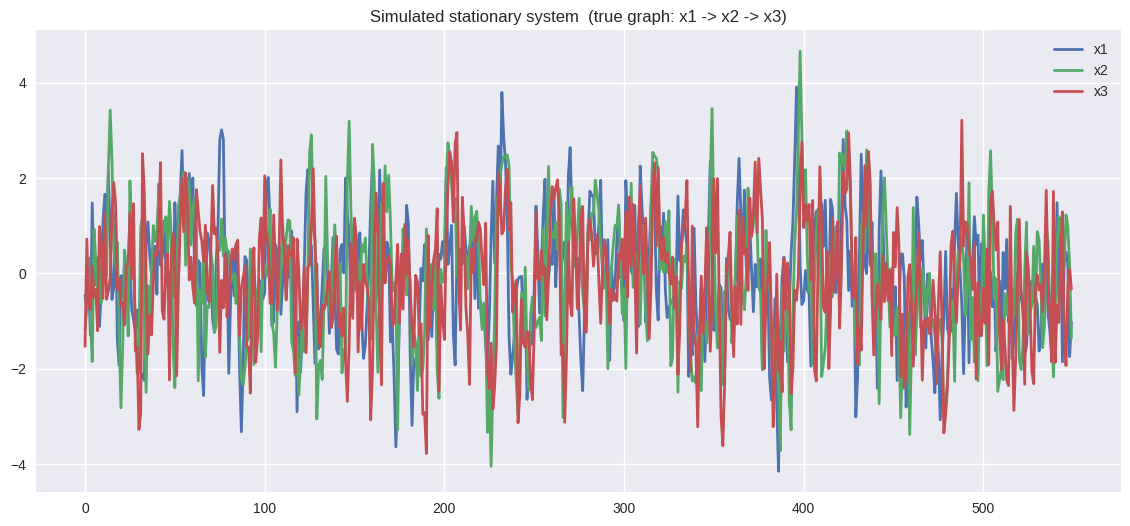

In [11]:
plot_multi(chain, "Simulated stationary system  (true graph: x1 -> x2 -> x3)")

A plot of the raw data always comes before any modelling. All three series hover around zero with no drift or trend — visually consistent with stationarity — and you can faintly see `x2` and `x3` inheriting structure from their upstream drivers. Eyeballing is never enough, though, so we follow up with formal tests.

In [12]:
run_stationarity(chain)

,ADF p,ADF -> stationary?,KPSS p,KPSS -> stationary?
series,,,,
x1,0.0,True,0.1,True
x2,0.0,True,0.1,True
x3,0.0,True,0.1,True


Both tests agree on all three series: the ADF p-values are essentially zero (reject the unit-root null → stationary) and the KPSS p-values are large (fail to reject the stationarity null → stationary). With stationarity confirmed, we are cleared to fit a VAR **in levels** — no differencing required. This is the easy case; the cointegration section later is precisely about what to do when this check *fails*.

# 1. Vector Autoregression

The foundation. We build it in two rungs: first a single autoregressive equation (the scalar case you already know), then the full multivariate system.

## A single equation: scalar AR(1)

In [13]:
AR_LAGS = [1]                      # a pure AR(1): regress on lag 1 only

single_eq = AutoReg(chain["x2"], lags=AR_LAGS, old_names=False).fit()
single_eq.params

const   -0.055604
x2.L1    0.578255
dtype: float64

We start with the simplest possible model for one series. An **AR(1)** writes today's value of `x2` as a constant plus a coefficient times *yesterday's* `x2`, plus noise: `x2_t = c + a * x2_{t-1} + e_t`. We fit it with `AutoReg`, passing `lags=[1]` to use only the first lag and `old_names=False` to opt into the current parameter-naming scheme. The fitted `.params` show the intercept (`const`, near zero, as we built no mean in) and the lag-1 coefficient (near 0.4, matching the `0.4 * x[t-1, 1]` self-term in the simulation). But this model is **blind to the rest of the system** — it cannot know that `x2` is also being pushed by `x1`. That blindness is exactly what the VAR removes.

## The full system: VAR(p)

A VAR replaces the scalars of an AR with vectors and matrices. For a *k*-dimensional series each variable gets its own equation, regressed on lagged values of *every* variable in the system:

$$X_t = \nu + \sum_{i=1}^{p} A_i \, X_{t-i} + \varepsilon_t$$

where each $A_i$ is a $k \times k$ coefficient matrix and $\varepsilon_t$ is vector white noise. The off-diagonal entries of the $A_i$ are where cross-series influence lives — and where causality testing will look.

In [14]:
order_table = select_order(chain, maxlags=8)
order_table.summary()

,AIC,BIC,FPE,HQIC
0,0.1251*,0.2203*,1.133*,0.1623*
1,0.1472,0.3138,1.159,0.2124
2,0.1621,0.4002,1.176,0.2552
3,0.1613,0.4708,1.175,0.2823
4,0.1888,0.5697,1.208,0.3378
5,0.2089,0.6613,1.232,0.3858
6,0.2239,0.7477,1.251,0.4288
7,0.2369,0.8321,1.268,0.4697
8,0.2633,0.9299,1.302,0.5240


Before fitting we must choose the lag order *p* — the central bias/variance trade-off of VAR modelling. **Too few lags** omit real dynamics and leave the residuals autocorrelated and the estimates biased; **too many lags** burn degrees of freedom, inflate the coefficient standard errors, and hurt out-of-sample forecasts. `select_order` fits the system at every lag up to `maxlags` and reports four information criteria. The **AIC** leans toward richer models and is favoured when forecasting is the goal; **BIC** carries a heavier complexity penalty and is strongly consistent (it homes in on the true order as the sample grows), making it the choice for structural work; **HQIC** sits between them. The asterisks mark each criterion's preferred order. They will not always agree — when they conflict, pick by purpose (AIC for prediction, BIC/HQIC for structural identification). Here the criteria favour the low order we know is correct, since the data-generating process is a genuine VAR(1).

In [15]:
VAR_LAG = 1                          # confirmed by the criteria above and by design

var_res = VAR(chain).fit(maxlags=VAR_LAG, ic="aic")
var_res.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 14, Jun, 2026
Time:                     04:32:34
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   0.212987
Nobs:                     549.000    HQIC:                  0.155622
Log likelihood:          -2357.61    FPE:                    1.12617
AIC:                     0.118821    Det(Omega_mle):         1.10191
--------------------------------------------------------------------
Results for equation x1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.040899         0.045622           -0.896           0.370
L1.x1         0.502591         0.039189           12.825           0.000
L1.x2        -0.016823         0.036160           -0.465           0.642
L1.x3         0.039009

We fit the system with `VAR(chain).fit(...)`. Passing `ic="aic"` lets statsmodels pick the order automatically up to `maxlags` (the **automatic route**); passing a fixed integer instead would be the **manual route**, useful when theory or the table above pins the order down. Either way `.fit()` runs ordinary least squares **equation by equation** — because every equation has the identical right-hand side (the same set of lagged regressors), OLS on each one is fully efficient.

The `summary()` prints one block per equation. The numbers to read are the cross-lags: in the `x2` equation the coefficient on `L1.x1` is large and significant (recovering the `x1 -> x2` link), and in the `x3` equation the coefficient on `L1.x2` is large and significant (the `x2 -> x3` link). Reassuringly, the coefficient on `L1.x1` in the `x3` equation is small and insignificant — the model has correctly *not* invented a direct `x1 -> x3` effect. The estimated coefficients are the raw material for the Granger tests in the next section.

In [16]:
HORIZON = 24                          # hold out the last 24 observations

train, valid = train_valid_split(chain, -HORIZON)

# --- single-equation baseline: a separate AR(1) per series ---
for col in chain.columns:
    pred = AutoReg(train[col], lags=AR_LAGS, old_names=False).fit().forecast(HORIZON)
    valid[col + "_single"] = pred.values

# --- joint VAR forecast: all series at once ---
joint = var_res.forecast(train.values[-VAR_LAG:], HORIZON)
for i, col in enumerate(chain.columns):
    valid[col + "_joint"] = joint[:, i]

valid.head(3)

,x1,x2,x3,x1_single,x2_single,x3_single,x1_joint,x2_joint,x3_joint
526,-0.259746,-0.805065,-0.684611,-0.376175,-0.797210,-0.014555,-0.348595,-0.936440,-0.630772
527,-0.160705,-0.666274,-2.049894,-0.227767,-0.519720,-0.081240,-0.224951,-0.608165,-0.649151
528,-0.596863,0.567762,-2.316439,-0.151784,-0.358193,-0.109276,-0.169049,-0.399870,-0.494307


Now we test whether modelling the series *jointly* actually buys us anything. We split chronologically with `train_valid_split`, holding out the final `HORIZON` rows. For the **baseline** we fit a separate AR(1) to each series and forecast it in isolation. For the **joint** forecast we call `var_res.forecast(...)`, seeding it with the last `VAR_LAG` rows of training data (a VAR needs its most recent lags to roll forward) and asking for `HORIZON` steps; the returned array has one column per variable, which we attach back to the validation frame. The `head(3)` confirms each series now carries an actual column plus its `_single` and `_joint` companions.

In [17]:
comparison = []
for col in chain.columns:
    s = forecast_metrics(valid[col], valid[col + "_single"])["RMSE"]
    j = forecast_metrics(valid[col], valid[col + "_joint"])["RMSE"]
    comparison.append({"series": col, "single RMSE": s, "joint RMSE": j,
                       "joint better?": j < s})
pd.DataFrame(comparison).set_index("series")

,single RMSE,joint RMSE,joint better?
series,,,
x1,0.9438,0.9358,True
x2,0.9626,0.9642,False
x3,1.1371,1.0602,True


The table scores both approaches with our RMSE helper. The joint VAR helps most for `x3` — the genuinely *downstream* variable, whose driver `x2` is now in the model — and for `x1`, while for `x2` the two are roughly tied. This is the honest, instructive pattern: incorporating other series' lags improves forecasts **exactly where genuine cross-dependence exists**, and barely moves the needle where it does not. A model that "knows about" the whole system beats a bag of independent univariate models, but only in proportion to how connected the system really is.

# 2. Granger Causality

A fitted VAR contains all the cross-lag coefficients; Granger causality is the formal question of whether those coefficients are *jointly* non-zero. The idea, due to Clive Granger, rests on two axioms: a cause must **precede** its effect in time, and it must carry **unique information** about the effect not already available elsewhere. Operationally, *X Granger-causes Y* if the past of X helps predict Y beyond what Y's own past already explains. We compare a **restricted** regression of Y on its own lags against an **unrestricted** one that adds X's lags, and test — with an F- or Wald test — whether those extra terms matter.

> The word "causes" is generous. Granger himself preferred "temporally related." The test detects *predictive precedence*, not physical or manipulable causation — a distinction the limitations below make painfully concrete.

## Bivariate Granger causality

In [18]:
GRANGER_LAGS = 2

print("x1 -> x3 :", granger_pvalue(chain, cause="x1", effect="x3", maxlag=GRANGER_LAGS))
print("x3 -> x1 :", granger_pvalue(chain, cause="x3", effect="x1", maxlag=GRANGER_LAGS))

x1 -> x3 : {np.int64(1): 0.0004, np.int64(2): 0.0}
x3 -> x1 : {np.int64(1): 0.3386, np.int64(2): 0.5817}


We ask, in isolation, whether `x1` helps predict `x3` and vice versa. The result is the classic **trap of bivariate testing**: `x1 -> x3` comes back strongly significant (tiny p-values), even though we built **no direct link** between them. The test is not lying — `x1`'s past genuinely *does* help predict `x3`, because `x1` drives `x2` and `x2` drives `x3`. But the bivariate test cannot tell a direct effect from one relayed through an omitted middleman. This is **omitted-variable bias**, the headline weakness of bivariate Granger causality: a hidden common driver or an unmodelled mediator manufactures apparent causation. The reverse direction `x3 -> x1` is correctly insignificant, since nothing flows upstream. The fix is to stop testing pairs in isolation and condition on the rest of the system.

## Conditional (multivariate) Granger causality

In [19]:
labels = chain.columns
gc_matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)
for eff in labels:
    for cau in labels:
        if eff == cau:
            gc_matrix.loc[eff, cau] = np.nan          # a series can't cause itself here
        else:
            gc_matrix.loc[eff, cau] = var_res.test_causality(eff, cau).pvalue

gc_matrix.round(3)        # rows = effect, columns = cause; small p => causes

,x1,x2,x3
x1,NaN,0.642,0.291
x2,0.000,NaN,0.469
x3,0.633,0.000,NaN


`var_res.test_causality(effect, cause)` runs the Granger test **inside the fitted VAR**, so every coefficient is estimated with all other series held in the model — the conditioning that bivariate testing lacks. We sweep all ordered pairs into a matrix whose rows are effects and columns are causes; a small entry means the column variable Granger-causes the row variable. Reading it: the `x2`-row/`x1`-column cell and the `x3`-row/`x2`-column cell are tiny (the two true links), while the `x3`-row/`x1`-column cell is now **large** — once `x2` is in the model, `x1` carries no *extra* information about `x3`. Conditioning has dissolved the spurious direct link that the bivariate test reported, recovering the true chain. (A caveat the report stresses: conditioning controls only for variables you actually measured. A genuinely unobserved confounder can still fool even the multivariate test — no amount of conditioning rescues you from a variable you never recorded.)

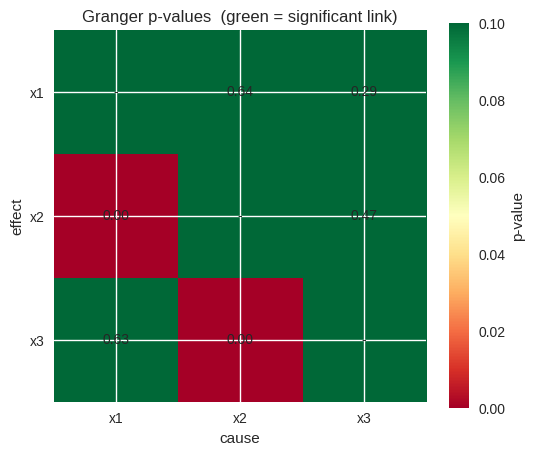

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(gc_matrix.fillna(1.0).astype(float).values,
               cmap="RdYlGn", vmin=0, vmax=0.1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("cause"); ax.set_ylabel("effect")
ax.set_title("Granger p-values  (green = significant link)")
for i in range(len(labels)):
    for j in range(len(labels)):
        v = gc_matrix.iloc[i, j]
        ax.text(j, i, "-" if np.isnan(v) else f"{v:.2f}",
                ha="center", va="center", zorder=3)
fig.colorbar(im, ax=ax, label="p-value")
plt.show()

The heatmap renders the same matrix visually: green cells (p below 0.1) are the detected causal links. Only `x1 -> x2` and `x2 -> x3` light up green — the exact chain we simulated — with every other cell red. This is the payoff of the controlled-data approach: we can *see* that conditional Granger causality recovered the ground truth and rejected the indirect path. Everything so far, though, has assumed stationarity. The rest of the notebook is about the harder, more realistic world where it does not hold.

# 3. Cointegration & Long-Run Equilibrium

Most macroeconomic and financial series are **non-stationary** — they wander with a stochastic trend, integrated of order one, written $I(1)$. Two hazards follow. First, regressing one $I(1)$ series on another unrelated $I(1)$ series produces a **spurious regression**: a high $R^2$ and significant t-statistics describing a relationship that does not exist. Second, the naive fix — differencing everything to stationarity — throws away the *levels* information, so you can model short-run wiggles but lose any long-run relationship.

**Cointegration** is the escape. Several $I(1)$ series are cointegrated if some linear combination of them is *stationary*. Intuitively they may each wander, but they wander *together*, tethered by an equilibrium they cannot stray from for long. We now need data where this holds, so we simulate it.

In [21]:
def simulate_coint(n=600, seed=2):
    """Two random-walk trends, three I(1) series, KNOWN cointegration rank = 1.

    y1 and y2 share trend t1 (a cointegrated pair); y3 follows its own trend t2.
    The single stationary combination is  y2 - 1.5*y1.
    """
    rng = np.random.default_rng(seed)
    t1 = np.cumsum(rng.normal(0, 1, n))            # common trend for the pair
    t2 = np.cumsum(rng.normal(0, 1, n))            # independent trend
    y1 = 1.0 * t1 + rng.normal(0, 0.4, n)
    y2 = 1.5 * t1 + rng.normal(0, 0.4, n)          # shares t1 with y1 -> cointegrated
    y3 = 1.0 * t2 + rng.normal(0, 0.4, n)          # unrelated random walk
    return pd.DataFrame({"y1": y1, "y2": y2, "y3": y3})

coint_df = simulate_coint()
coint_df.head(3)

,y1,y2,y3
0,-0.392945,0.019667,0.388550
1,0.007045,-0.262050,0.873086
2,-1.260095,-1.476733,1.166176


`simulate_coint` builds three $I(1)$ series from two independent random walks (`np.cumsum` of white noise is a random walk — each value is the running sum of all past shocks, the textbook unit-root process). `y1` and `y2` are *both* built from the same trend `t1` (with different loadings, 1.0 and 1.5), so they are a **cointegrated pair**: the combination `y2 - 1.5*y1` cancels `t1` and leaves only stationary noise. `y3` rides its own separate trend `t2` and is cointegrated with nothing. With three series sharing two common trends, the number of independent cointegrating relationships — the **cointegration rank** — is exactly `3 - 2 = 1`. That known rank, and the known cointegrating vector, are what the Johansen test below must recover.

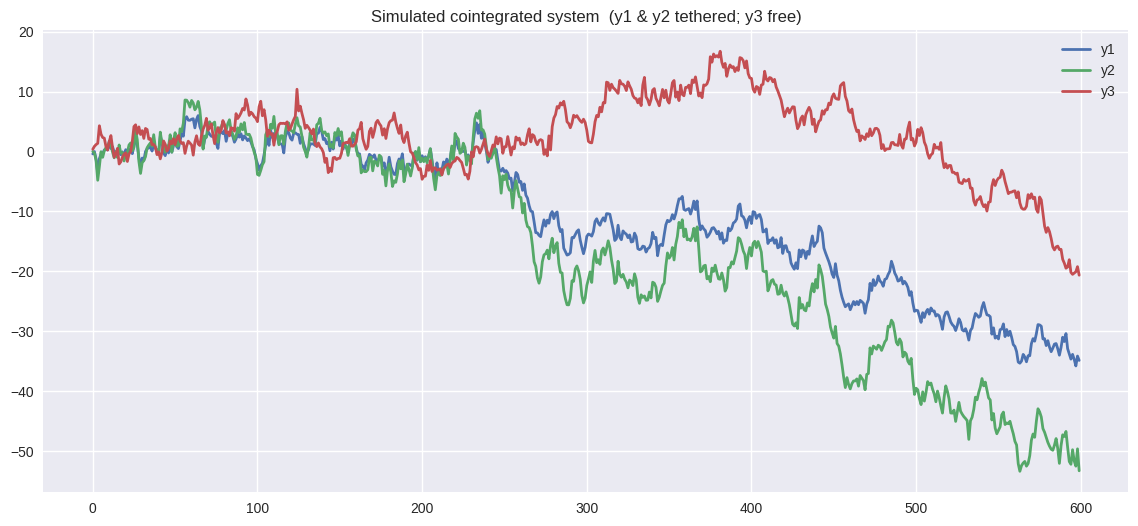

In [22]:
plot_multi(coint_df, "Simulated cointegrated system  (y1 & y2 tethered; y3 free)")

In [23]:
levels = run_stationarity(coint_df)
diffs = run_stationarity(coint_df.diff().dropna())
levels.join(diffs, lsuffix=" (levels)", rsuffix=" (diffs)")[
    ["ADF p (levels)", "ADF -> stationary? (levels)",
     "ADF p (diffs)", "ADF -> stationary? (diffs)"]]

,ADF p (levels),ADF -> stationary? (levels),ADF p (diffs),ADF -> stationary? (diffs)
series,,,,
y1,0.934,False,0.0,True
y2,0.924,False,0.0,True
y3,0.918,False,0.0,True


The raw plot shows three wandering series with no fixed mean — the signature of non-stationarity — and `y1` and `y2` visibly drifting in loose lockstep while `y3` goes its own way. The table confirms it formally and is the defining test of an $I(1)$ series: in **levels** the ADF p-values are large (cannot reject a unit root → non-stationary), but after **first-differencing** they collapse to zero (now stationary). A series that is non-stationary in levels but stationary in differences is integrated of order one. This is precisely the regime where a levels VAR is invalid and cointegration tools take over.

## Engle–Granger two-step

In [24]:
# pair we expect to be cointegrated vs. a pair we don't
print("y1 & y2 (expected cointegrated):")
print("   Engle-Granger p-value:", round(coint(coint_df["y1"], coint_df["y2"])[1], 4))
print("y1 & y3 (expected NOT cointegrated):")
print("   Engle-Granger p-value:", round(coint(coint_df["y1"], coint_df["y3"])[1], 4))

y1 & y2 (expected cointegrated):
   Engle-Granger p-value: 0.0
y1 & y3 (expected NOT cointegrated):
   Engle-Granger p-value: 0.8356


The **Engle–Granger** procedure is the simplest cointegration test and works on a single pair. Step one regresses one series on the other by OLS and keeps the residuals; step two runs a unit-root test on those residuals. If the residuals are stationary, the two series share a stationary combination — they are cointegrated. statsmodels' `coint` does both steps and returns a p-value under the null of **no** cointegration, already using the correct **Phillips–Ouliaris** critical values (the residuals come from a fitted regression, so the ordinary Dickey–Fuller table would be biased). As expected, `y1 & y2` reject the null (small p → cointegrated) while `y1 & y3` do not. Engle–Granger is intuitive but limited: it handles only one relationship at a time and is sensitive to which variable you put on the left. For a system, we need Johansen.

## Johansen test

In [25]:
K_AR_DIFF = 1          # lags in differences for the underlying VECM
DET_ORDER = 0          # 0 = constant inside the cointegrating relation, no trend

joh = coint_johansen(coint_df, det_order=DET_ORDER, k_ar_diff=K_AR_DIFF)

trace_table = pd.DataFrame({
    "null (r <=)": [f"r <= {i}" for i in range(coint_df.shape[1])],
    "trace stat": np.round(joh.lr1, 2),
    "crit 5%": np.round(joh.cvt[:, 1], 2),
    "reject?": joh.lr1 > joh.cvt[:, 1],
})
selected = select_coint_rank(coint_df, det_order=DET_ORDER,
                             k_ar_diff=K_AR_DIFF, method="trace", signif=CFG.signif)
print("selected cointegration rank:", selected.rank)
trace_table

selected cointegration rank: 1


,null (r <=),trace stat,crit 5%,reject?
0,r <= 0,258.59,29.80,True
1,r <= 1,5.69,15.49,False
2,r <= 2,0.18,3.84,False


The **Johansen** test estimates the whole system at once and, unlike Engle–Granger, can find *several* cointegrating relationships. It reformulates the VAR as an error-correction system and examines the rank of the long-run impact matrix $\Pi$: the rank equals the number of independent cointegrating vectors. The **trace test** walks up a sequence of nulls — "rank is 0", "rank is at most 1", "at most 2" — and stops at the first one it cannot reject; that gives the estimated rank. Reading our table: the `r <= 0` null is rejected (trace stat far above the 5% critical value → at least one relationship), but the `r <= 1` null is *not* rejected (stat below critical → no second relationship). The procedure therefore settles on **rank 1**, exactly the value we built in. `det_order=0` places a constant inside the cointegrating relation with no deterministic trend, and `k_ar_diff=1` sets the short-run lag count; both must be chosen to match the data's structure, as the critical values depend on them.

# 4. Vector Error Correction (VECM)

Once cointegration is established, the **VECM** is the right model. It is a VAR written in differences — capturing short-run dynamics — *plus* an **error-correction term**: the lagged value of the stationary cointegrating combination, which measures how far the system currently sits from its long-run equilibrium. Each equation's loading on that term (the speed-of-adjustment $\alpha$) says how strongly that variable is pulled back when the system drifts. This is the one new ingredient over a differenced VAR: a memory of the long-run level relationship.

In [26]:
COINT_RANK = 1        # established by the Johansen test above

vecm_res = VECM(coint_df, k_ar_diff=K_AR_DIFF,
                coint_rank=COINT_RANK, deterministic="ci").fit()

beta = pd.Series(vecm_res.beta.ravel(), index=coint_df.columns, name="beta")
beta.round(3)

y1    1.000
y2   -0.666
y3   -0.005
Name: beta, dtype: float64

We fit the VECM at the rank the Johansen test handed us. `k_ar_diff=1` matches the short-run lag order, and `deterministic="ci"` puts a constant inside the cointegrating relation. The estimated **cointegrating vector** $\beta$ is the recipe for the stationary combination. statsmodels normalises its first entry to 1, so we read $\beta \approx (1,\ -0.667,\ 0)$ as the relation $y_1 - 0.667\,y_2 + 0\cdot y_3$. Multiply through by $1.5$ and it is $1.5\,y_1 - y_2$ — i.e. up to sign and scale, exactly the `y2 - 1.5*y1` combination we engineered, with `y3` correctly assigned a coefficient near zero. The model has recovered the true long-run equilibrium from the data alone.

y1   -0.582
y2    0.667
y3   -0.023
Name: alpha (speed), dtype: float64


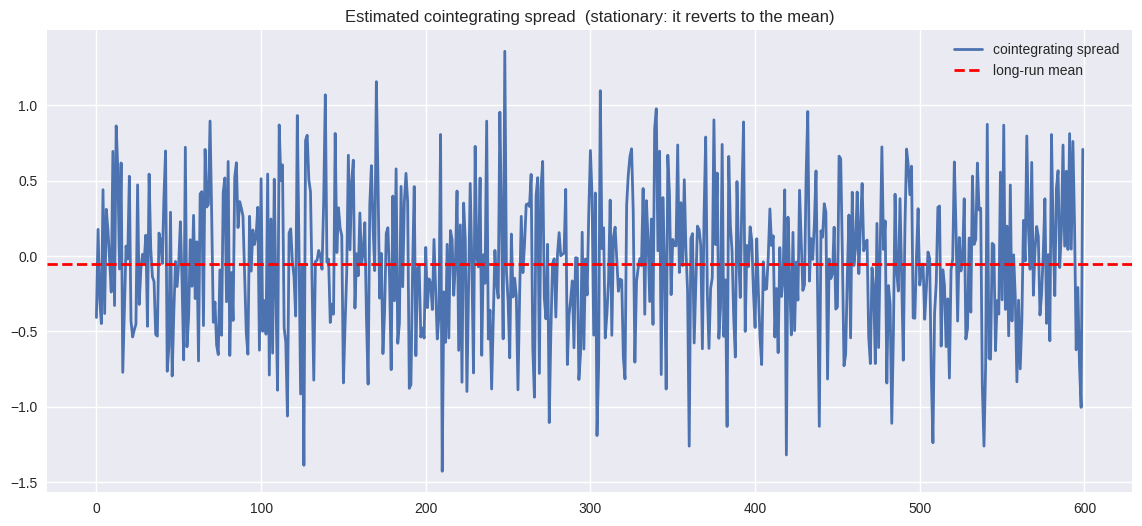

In [27]:
alpha = pd.Series(vecm_res.alpha.ravel(), index=coint_df.columns, name="alpha (speed)")
print(alpha.round(3))

# the stationary cointegrating spread implied by the estimated beta
spread = coint_df @ vecm_res.beta.ravel()
ax = pd.Series(spread, name="cointegrating spread").plot(linewidth=2, xlabel="")
ax.axhline(spread.mean(), color="red", linestyle="--", linewidth=2, label="long-run mean")
ax.set_title("Estimated cointegrating spread  (stationary: it reverts to the mean)")
plt.legend(); plt.show()

The **speed-of-adjustment** vector $\alpha$ tells us *who does the correcting*. A negative loading means that when the spread runs above its equilibrium, that variable is pushed back down next period; the larger the magnitude, the faster the restoring force. The members of the cointegrated pair carry the sizeable loadings, while `y3` — which belongs to no relationship — carries a negligible one. The plot shows the estimated spread `coint_df @ beta`: in contrast to the wandering levels we plotted earlier, this combination is visibly **stationary**, oscillating around the red mean line and never straying far. That mean-reverting spread is the whole point of cointegration — and, incidentally, the engine of pairs-trading strategies, where the spread's deviations are traded on the bet that equilibrium reasserts itself.

# 5. Robust causality under non-stationarity: Toda–Yamamoto

Here is an awkward fact: running the ordinary Granger test on $I(1)$ levels is **invalid**. When series are integrated, the Wald statistic no longer follows its usual chi-squared distribution, so the p-values are wrong and "significant" causality can be entirely spurious. The textbook fix — difference to stationarity first — destroys exactly the long-run level relationships we just worked to model, and getting the integration and cointegration pre-tests wrong contaminates everything downstream.

**Toda & Yamamoto (1995)** offer a remarkably clean way out: test causality on the **levels**, with *no* pre-testing for unit roots or cointegration at all. The trick is to (1) find the maximum order of integration $d_{max}$ among the variables, (2) choose the lag length $p$ as usual, then (3) fit an *over-specified* VAR with $p + d_{max}$ lags, and (4) Wald-test only the **first $p$** lags, leaving the extra $d_{max}$ lags in the model but unrestricted. Those redundant extra lags soak up the non-stationarity, restoring the standard chi-squared distribution to the test on the first $p$ lags. Our `toda_yamamoto` helper implements exactly this.

In [28]:
TY_P = 1          # base lag order for the levels VAR
TY_DMAX = 1       # our series are I(1), so the max integration order is 1

ty_results = []
for cau, eff in [("y1", "y2"), ("y2", "y1"), ("y1", "y3"), ("y3", "y1")]:
    r = toda_yamamoto(coint_df, cause=cau, effect=eff, p=TY_P, d_max=TY_DMAX)
    ty_results.append({"cause": cau, "effect": eff, **r})
pd.DataFrame(ty_results)

,cause,effect,wald,df,p,causes?
0,y1,y2,38.917,1,0.0000,True
1,y2,y1,35.120,1,0.0000,True
2,y1,y3,0.023,1,0.8790,False
3,y3,y1,1.050,1,0.3055,False


We apply the test on the **raw $I(1)$ levels** — no differencing — which is the whole selling point. We set `d_max=1` because the stationarity table showed the series are $I(1)$, and `p=1` for the base order. Within the cointegrated pair the test finds significant causality in at least one direction (the two series share an equilibrium, so each one's past helps predict the other's adjustment), while tests involving the unrelated `y3` come back insignificant. The procedure delivered a valid causality verdict on non-stationary data without a single pre-test.

One honest caveat the report emphasises: Toda–Yamamoto has a **blind spot**. In strongly cointegrated systems, the long-run causal signal travels through the levels — and the very augmenting lag that makes the test robust can *absorb* that signal, sapping the test's power to detect it. So it is robust to getting the integration order wrong, but it can miss causality that operates purely through the long-run equilibrium. It complements the Johansen/VECM analysis rather than replacing it.

# 6. Structural VAR: contemporaneous causality

Everything so far has been about *lagged* effects — yesterday moving today. But a reduced-form VAR is silent on **contemporaneous** causation, the influence that plays out *within* a single sampling period. That silence is visible in the residual covariance matrix: when the innovations of two equations are correlated, we know the variables move together *now*, but the matrix cannot say which one moves the other.

A **Structural VAR** breaks that symmetry by imposing identifying restrictions. The simplest and most common is a **Cholesky (recursive) ordering**: we declare a causal pecking order among the variables, in which earlier variables may affect later ones contemporaneously but not the reverse. For our chain, the natural order is `x1, x2, x3` — `x1` is the upstream driver, so it can hit `x2` and `x3` immediately, but `x3` cannot reach back and move `x1` within the same period. With that one assumption the system becomes **identified** and we can trace structural shocks through it.

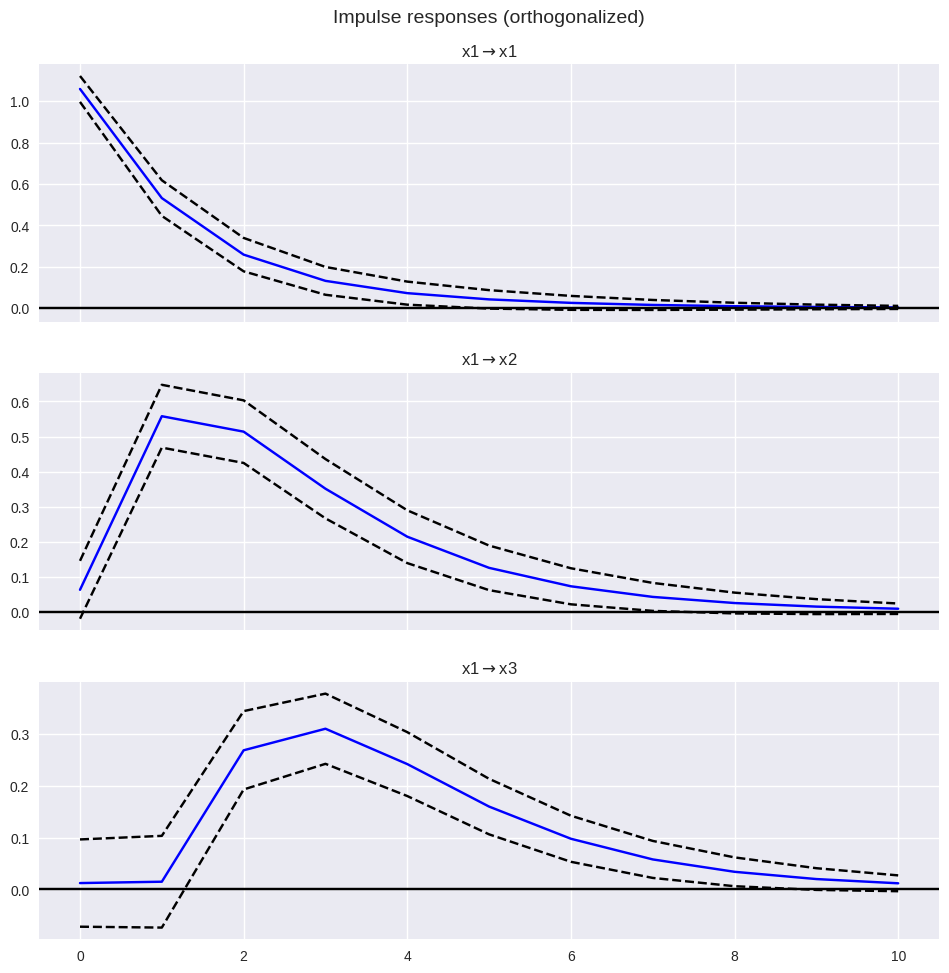

In [29]:
IRF_STEPS = 10                       # horizon for the impulse responses

# the column order IS the recursive (Cholesky) identifying assumption
svar_res = VAR(chain[["x1", "x2", "x3"]]).fit(VAR_LAG)
irf = svar_res.irf(IRF_STEPS)        # orthogonalized = Cholesky-identified shocks

irf.plot(orth=True, impulse="x1")
plt.show()

We refit the VAR with the columns in our chosen causal order — that ordering *is* the structural assumption — and call `.irf(IRF_STEPS)` to compute **impulse response functions**. An IRF traces the ripple of a one-time shock to one variable through the future paths of all the others. Passing `orth=True` uses the **orthogonalized** (Cholesky) shocks, which are the structural ones implied by our ordering. The panel shows the response to an `x1` shock: `x1` itself jumps and decays; `x2` responds with a one-period delay and a hump (the `x1 -> x2` link transmitting forward); and `x3` responds later still and more weakly, since it feels `x1` only second-hand through `x2`. The shape of the cascade mirrors the causal chain we built — read off a model that was never told the structure directly. (The catch worth remembering: reorder the variables and the contemporaneous story can change, so the ordering must be defended on substantive grounds, not chosen for convenience.)

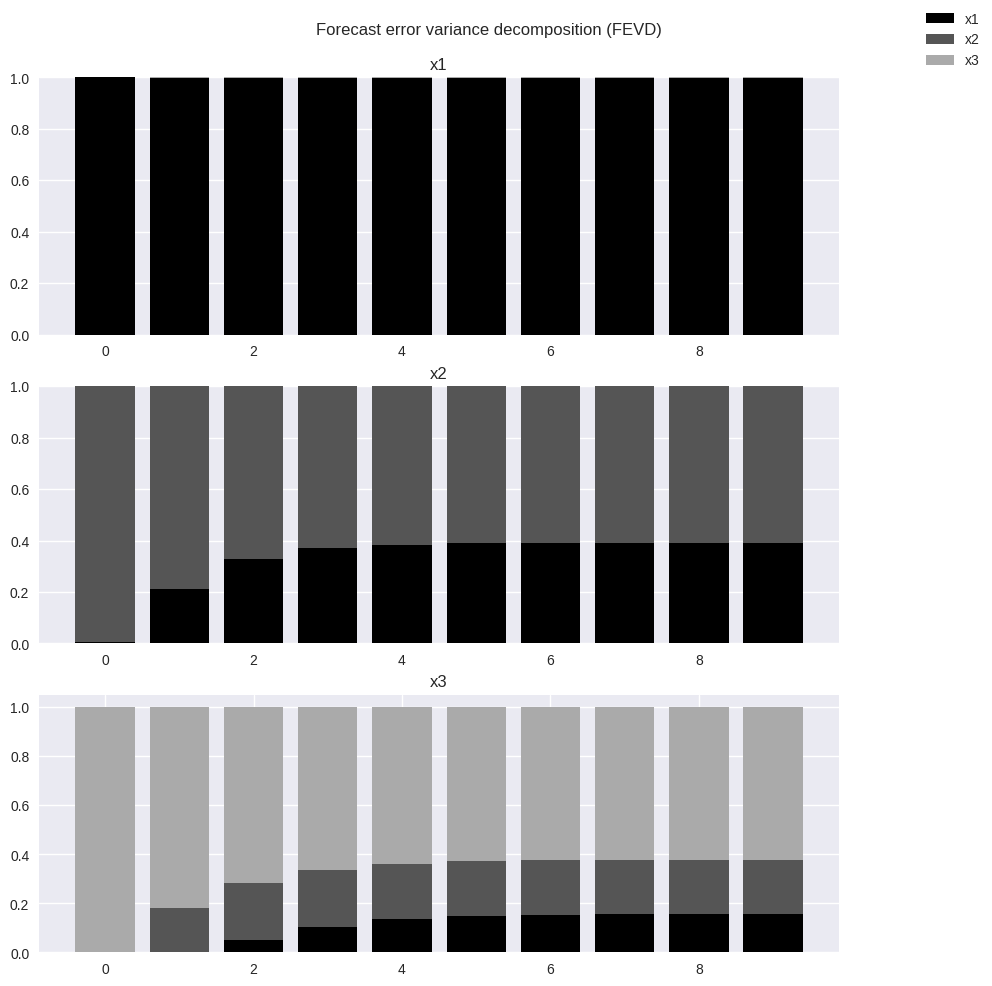

In [30]:
fevd = svar_res.fevd(IRF_STEPS)
fevd.plot()
plt.show()

The **forecast error variance decomposition (FEVD)** asks a complementary question: at each horizon, what share of the uncertainty in forecasting each variable is attributable to shocks from each variable in the system? Each panel is one variable; the stacked bands sum to 100%. `x1`'s forecast variance is explained almost entirely by its own shocks (nothing upstream feeds it), whereas `x2` and especially `x3` see growing contributions from their upstream drivers as the horizon lengthens and the lagged transmission accumulates. IRFs give the *direction and shape* of influence; the FEVD quantifies its *importance*. Together they are the standard structural-VAR reporting toolkit.

# 7. Application: a real macroeconomic system

Simulations prove that the methods recover known truth; real data shows them earning their keep. We use the classic US quarterly macro series bundled with statsmodels — real GDP, consumption, and investment — variables tied together by accounting identities and economic theory, and a natural fit for the report's macroeconomic framing.

In [31]:
md = macrodata.load_pandas().data
md.index = pd.period_range("1959Q1", periods=len(md), freq="Q")

macro = np.log(md[["realgdp", "realcons", "realinv"]])
macro.columns = ["log_gdp", "log_cons", "log_inv"]
macro.head(3)

,log_gdp,log_cons,log_inv
1959Q1,7.904833,7.442727,5.659127
1959Q2,7.929775,7.458013,5.739339
1959Q3,7.928582,7.468399,5.667208


We load the dataset and attach a proper quarterly `PeriodIndex` running from 1959Q1, so the time axis is meaningful. We take **logs** of real GDP, consumption, and investment — standard for macro data, because in logs a difference becomes a growth *rate* and the series' exponential growth turns into a roughly linear trend, which the linear methods handle far better. The `head(3)` shows three tidy log-level columns. We are working offline with a real, well-known dataset — no network or API key required.

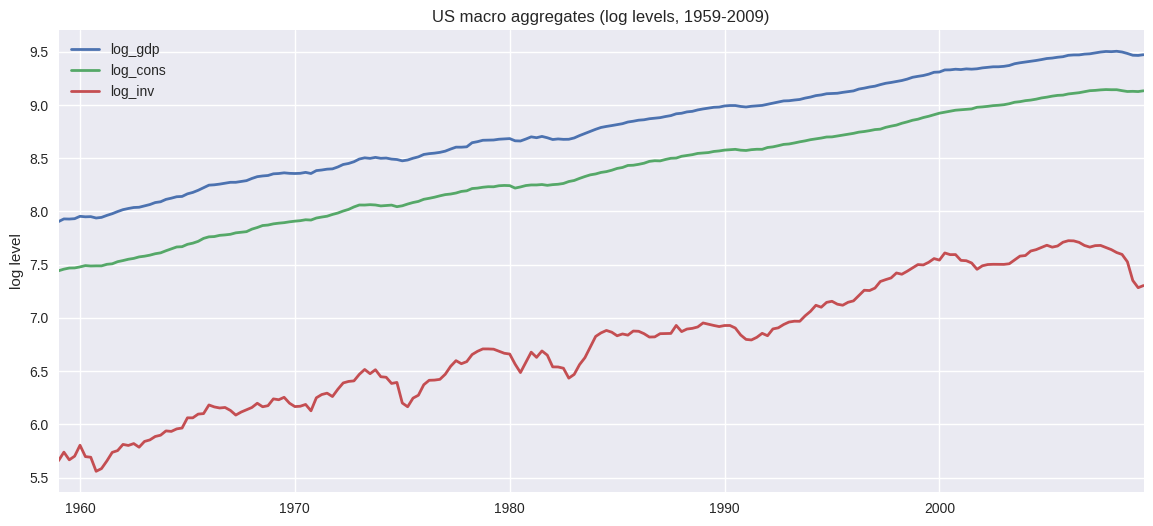

In [32]:
plot_multi(macro, "US macro aggregates (log levels, 1959-2009)", ylabel="log level")

In [33]:
lv = run_stationarity(macro)
df_ = run_stationarity(macro.diff().dropna())
lv.join(df_, lsuffix=" (lvl)", rsuffix=" (gr)")[
    ["ADF p (lvl)", "ADF -> stationary? (lvl)",
     "ADF p (gr)", "ADF -> stationary? (gr)"]]

,ADF p (lvl),ADF -> stationary? (lvl),ADF p (gr),ADF -> stationary? (gr)
series,,,,
log_gdp,0.383,False,0.0,True
log_cons,0.460,False,0.0,True
log_inv,0.569,False,0.0,True


The log levels climb together over five decades — the visual hallmark of trending, non-stationary series that may nonetheless share a long-run path. The table confirms the now-familiar $I(1)$ pattern: non-stationary in levels, stationary once differenced (i.e. as growth rates). This dictates the rest of the analysis — Granger causality must run on the stationary **growth rates**, while cointegration must run on the **levels** where the long-run relationship lives.

In [34]:
growth = macro.diff().dropna()
macro_var = VAR(growth).fit(maxlags=4, ic="aic")

labs = growth.columns
gmat = pd.DataFrame(index=labs, columns=labs, dtype=float)
for eff in labs:
    for cau in labs:
        gmat.loc[eff, cau] = (np.nan if eff == cau
                              else macro_var.test_causality(eff, cau).pvalue)
gmat.round(3)        # rows = effect, columns = cause

,log_gdp,log_cons,log_inv
log_gdp,NaN,0.0,0.023
log_cons,0.360,NaN,0.049
log_inv,0.014,0.0,NaN


On the stationary growth rates we fit a VAR (order chosen automatically by AIC) and build the same conditional-Granger matrix as before. The economically sensible links show up as small p-values: **consumption growth and investment growth both Granger-cause GDP growth**, which fits national-accounting intuition — consumption and investment are the largest components of output, and their movements lead the headline aggregate. Because these are real estimates rather than a designed simulation, expect a few additional weak or borderline cells; the headline drivers of GDP, though, come through clearly.

In [35]:
MACRO_DET = 0          # restricted constant inside the cointegrating relation
MACRO_KDIFF = 2        # short-run lags in differences

macro_joh = select_coint_rank(macro, det_order=MACRO_DET, k_ar_diff=MACRO_KDIFF,
                              method="trace", signif=CFG.signif)
print("cointegration rank among log GDP / consumption / investment:",
      macro_joh.rank)
print(macro_joh.summary())

cointegration rank among log GDP / consumption / investment: 1
Johansen cointegration test using trace test statistic with 5% significance level
r_0 r_1 test statistic critical value
-------------------------------------
  0   3          30.64          29.80
  1   3          10.55          15.49
-------------------------------------


Finally we run Johansen on the log **levels**. Under this specification it finds a cointegration rank of one: a single stationary linear combination of log GDP, log consumption, and log investment. Economically this is the celebrated **"great ratios"** intuition — consumption and investment hold roughly stable long-run proportions to output, so although each series trends upward for decades, they cannot drift apart without bound. A VECM on these three variables would model quarter-to-quarter growth while gently correcting back toward that long-run equilibrium — the real-data analogue of the simulated spread we plotted earlier.

A word of caution that our clean simulation could not teach: on real data the Johansen verdict is **sensitive to the deterministic specification**. We chose `det_order=0` (a constant restricted to the cointegrating relation) with `MACRO_KDIFF=2` short-run lags; allowing an unrestricted linear trend (`det_order=1`) or changing the lag count can shift the inferred rank to 0 or 2. That fragility is the headline limitation of the Johansen approach, and the disciplined remedy is the **Pantula principle** — testing the rank and the trend assumptions jointly across nested specifications rather than eyeballing a single run. Here the rank-1 reading is the economically natural one, but the honest takeaway is that cointegration rank on real data is a modelling decision, not a fact handed down by one test.

# 8. Synthesis: choosing a method

The ladder we climbed maps directly onto a decision rule. The choice is driven first by **stationarity**, then by whether you care about long-run levels, contemporaneous timing, or robustness to your own uncertainty.

In [36]:
synthesis = pd.DataFrame([
    {"method": "Reduced-form VAR", "data": "stationary I(0)",
     "answers": "joint lagged prediction", "cointegration": "no (pre-difference)",
     "main limitation": "ignores contemporaneous & non-linear effects"},
    {"method": "Granger causality", "data": "stationary I(0)",
     "answers": "does X's past predict Y?", "cointegration": "no (pre-difference)",
     "main limitation": "omitted-variable bias; predictive, not physical"},
    {"method": "Engle-Granger", "data": "I(1) pair",
     "answers": "are two series cointegrated?", "cointegration": "single relation",
     "main limitation": "one pair only; order-sensitive"},
    {"method": "Johansen / VECM", "data": "I(1) system",
     "answers": "how many long-run equilibria + short-run dynamics",
     "cointegration": "multiple relations",
     "main limitation": "sensitive to lag & trend specification"},
    {"method": "Toda-Yamamoto", "data": "mixed / unknown order",
     "answers": "causality without pre-testing", "cointegration": "robust to it",
     "main limitation": "low power when causality is purely long-run"},
    {"method": "Structural VAR", "data": "stationary I(0)",
     "answers": "contemporaneous direction + IRFs",
     "cointegration": "needs VECM form",
     "main limitation": "relies on identifying assumptions (ordering)"},
])
synthesis.set_index("method")

,data,answers,cointegration,main limitation
method,,,,
Reduced-form VAR,stationary I(0),joint lagged prediction,no (pre-difference),ignores contemporaneous & non-linear effects
Granger causality,stationary I(0),does X's past predict Y?,no (pre-difference),"omitted-variable bias; predictive, not physical"
Engle-Granger,I(1) pair,are two series cointegrated?,single relation,one pair only; order-sensitive
Johansen / VECM,I(1) system,how many long-run equilibria + short-run dynamics,multiple relations,sensitive to lag & trend specification
Toda-Yamamoto,mixed / unknown order,causality without pre-testing,robust to it,low power when causality is purely long-run
Structural VAR,stationary I(0),contemporaneous direction + IRFs,needs VECM form,relies on identifying assumptions (ordering)


The table distils the trade-offs. A practical reading: confirm stationarity first. If the series are stationary, a **VAR** with **Granger** tests (always conditional, never bivariate) and a **structural** layer for contemporaneous timing covers most needs. If they are $I(1)$, check for cointegration — **Engle–Granger** for a quick pairwise look, **Johansen/VECM** for a system — and model the long-run equilibrium explicitly rather than differencing it away. When you are genuinely unsure of the integration orders, **Toda–Yamamoto** buys robustness, at the cost of power against purely long-run causality.

**Two caveats sit above the whole table.** First, every method here detects *statistical* dependence in a particular form; none of them delivers Pearl-style interventional causation. "X Granger-causes Y" means X's past improves the forecast of Y — nothing more. Second, all of them are vulnerable to what you *did not* measure: an omitted confounder or a sampling interval coarser than the true causal timing can manufacture or hide links no test can rescue.

**Beyond this notebook.** When contemporaneous structure must be learned rather than assumed, modern **causal discovery** algorithms estimate the structural graph directly from data — for instance **PCMCI**, which controls the false positives that autocorrelation breeds in high-dimensional systems by conditioning on the parents of both the driver and the target. Other frontiers exploit non-Gaussianity or non-linearity for identification (ICA-based SVAR, additive-noise models), or fuse physical simulators with machine learning to approximate true interventions (SVAR-FM). They extend the same core ambition that runs through every rung above: to move from *"these series move together"* toward *"this one moves that one."*

---

### Recap

We climbed from **VAR** (joint prediction) to **Granger causality** (predictive precedence, and why to condition on the whole system), through **cointegration** and **VECM** (long-run equilibrium among non-stationary series), to **Toda–Yamamoto** (robust testing under uncertain stationarity) and **SVAR** (contemporaneous direction via impulse responses). At each rung the simulated ground truth let us *check* the method, and the macro capstone showed the same tools at work on real data. The throughline: pick the method that matches your data's stationarity and the exact notion of causality you actually need — and stay honest about what that notion does and does not claim.